In [1]:
!python -m pip install scikit-learn sentence-transformers matplotlib seaborn

  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

PROJECT_ROOT = Path("/Users/apple/Desktop/UCL/skills/python3")
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "plots"

EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
landform_clean = pd.read_csv(CLEANED_DIR / "landforms_clean.csv")
climate_clean = pd.read_csv(CLEANED_DIR / "climate_clean.csv")
gutenberg_clean = pd.read_csv(CLEANED_DIR / "gutenberg_clean.csv")

In [4]:
all_df = pd.concat([
    landform_clean.assign(dataset_label="landforms"),
    climate_clean.assign(dataset_label="climate"),
    gutenberg_clean.assign(dataset_label="gutenberg")
], ignore_index=True)

print("all rows:", len(all_df))
all_df[["dataset_label", "page_title", "cleaned_text"]].head()

all rows: 1793


,dataset_label,page_title,cleaned_text
0,landforms,Desert,A desert is a landscape where little precipita...
1,landforms,Desert,Deserts are formed by weathering processes as ...
2,landforms,Desert,Plants and animals living in the desert need s...
3,landforms,Desert,People have struggled to live in deserts and t...
4,landforms,Desert,English desert and its Romance cognates (inclu...


In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(all_df["cleaned_text"])

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (1793, 3000)


In [6]:
import pickle

with open(EMBEDDINGS_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

with open(EMBEDDINGS_DIR / "tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)

In [7]:
def get_top_tfidf_terms(texts, vectorizer, top_n=15):
    matrix = vectorizer.transform(texts)
    mean_scores = np.asarray(matrix.mean(axis=0)).ravel()
    feature_names = np.array(vectorizer.get_feature_names_out())
    top_idx = mean_scores.argsort()[::-1][:top_n]
    return pd.DataFrame({
        "term": feature_names[top_idx],
        "score": mean_scores[top_idx]
    })

top_landforms = get_top_tfidf_terms(landform_clean["cleaned_text"], tfidf_vectorizer)
top_climate = get_top_tfidf_terms(climate_clean["cleaned_text"], tfidf_vectorizer)
top_gutenberg = get_top_tfidf_terms(gutenberg_clean["cleaned_text"], tfidf_vectorizer)

top_landforms

,term,score
0,coral,0.034474
1,water,0.031250
2,wetlands,0.030963
3,reefs,0.030359
4,islands,0.029463
5,reef,0.026140
6,desert,0.023254
7,species,0.022680
8,ice,0.022282
9,caves,0.020777


In [8]:
top_climate

,term,score
0,ice,0.049673
1,permafrost,0.046197
2,erosion,0.037955
3,drought,0.029737
4,water,0.029669
5,geothermal,0.028163
6,sea,0.024187
7,atmosphere,0.023518
8,soil,0.023355
9,sea ice,0.021747


In [9]:
top_gutenberg

,term,score
0,indian,0.025424
1,like,0.023251
2,said,0.023071
3,long,0.021223
4,feet,0.021127
5,lake,0.019547
6,valley,0.018351
7,miles,0.018011
8,day,0.017228
9,trees,0.016822


In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/Users/apple/Desktop/UCL/skills/python3/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13316.07it/s]


In [11]:
sentence_embeddings = model.encode(
    all_df["cleaned_text"].tolist(),
    show_progress_bar=True
)

sentence_embeddings = np.array(sentence_embeddings)
print("Sentence embeddings shape:", sentence_embeddings.shape)

Batches: 100%|██████████| 57/57 [00:20<00:00,  2.74it/s]

Sentence embeddings shape: (1793, 384)


In [12]:
np.save(EMBEDDINGS_DIR / "sentence_embeddings.npy", sentence_embeddings)
all_df.to_csv(EMBEDDINGS_DIR / "all_texts_with_labels.csv", index=False)

In [13]:
pca_tfidf = PCA(n_components=2)
tfidf_2d = pca_tfidf.fit_transform(tfidf_matrix.toarray())

pca_sentence = PCA(n_components=2)
sentence_2d = pca_sentence.fit_transform(sentence_embeddings)

print(tfidf_2d.shape, sentence_2d.shape)

(1793, 2) (1793, 2)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df_tfidf = all_df.copy()
plot_df_tfidf["x"] = tfidf_2d[:, 0]
plot_df_tfidf["y"] = tfidf_2d[:, 1]

plot_df_sentence = all_df.copy()
plot_df_sentence["x"] = sentence_2d[:, 0]
plot_df_sentence["y"] = sentence_2d[:, 1]

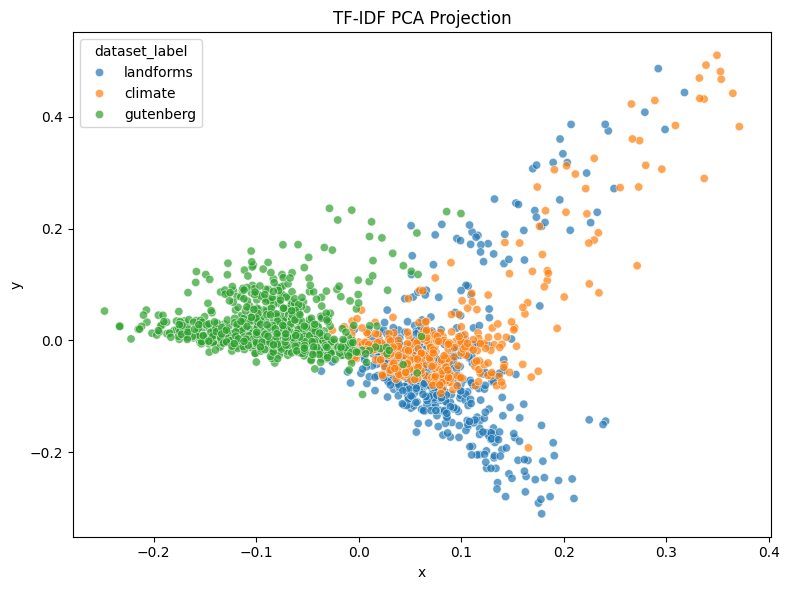

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df_tfidf, x="x", y="y", hue="dataset_label", alpha=0.7)
plt.title("TF-IDF PCA Projection")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "tfidf_pca.png", dpi=300)
plt.show()

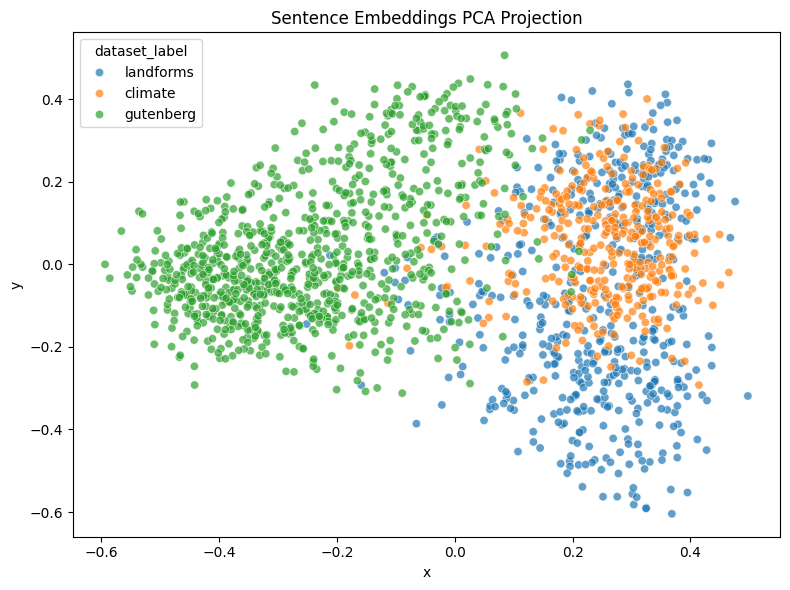

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df_sentence, x="x", y="y", hue="dataset_label", alpha=0.7)
plt.title("Sentence Embeddings PCA Projection")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "sentence_pca.png", dpi=300)
plt.show()